In [ ]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 16.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()  # pick 2-3 images from your device

In [ ]:
def read_prominent_text(image_path):
    import math

    results = reader.readtext(image_path)
    print(results)
    for bbox,text,confidence in results:
      top_left = bbox[0]
      bottom_right = bbox[2]
      width = math.dist(bbox[0], bbox[1])
      height = math.dist(bbox[1], bbox[2])
      area = width * height
      if area >= 4000:
        print(f"KEPT → Text: {text} | Area: {area}")
# [44,40] ,[60,77]

      print(f"Text: {text} | Confidence: {confidence:.2f} | Area: {area}")

In [ ]:
read_prominent_text(image_name)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[([[np.int32(373), np.int32(95)], [np.int32(451), np.int32(95)], [np.int32(451), np.int32(131)], [np.int32(373), np.int32(131)]], 'Close to', np.float64(0.7206596022620979)), ([[np.float64(377.42913985468846), np.float64(58.77165594187538)], [np.float64(548.3307953686663), np.float64(21.246344114198916)], [np.float64(557.5708601453116), np.float64(67.22834405812462)], [np.float64(386.6692046313338), np.float64(104.75365588580108)]], "'HOSPITAL", np.float64(0.9856196573528551)), ([[np.float64(263.5278640450004), np.float64(91.76393202250021)], [np.float64(390.26640916825977), np.float64(61.39274995273013)], [np.float64(399.4721359549996), np.float64(101.23606797749979)], [np.float64(273.73359083174023), np.float64(132.60725004726987)]], 'MEDSPLY', np.float64(0.9994141601370485)), ([[np.float64(447.2802656784306), np.float64(85.38855792470427)], [np.float64(520.5218843996887), np.float64(80.10360070785993)], [np.float64(521.7197343215694), np.float64(113.61144207529573)], [np.float64(448

In [ ]:
import easyocr

reader = easyocr.Reader(['en'])  # loads the model, only needs to run once per session

image_name = list(uploaded.keys())[0]  # grabs the first uploaded file
result = reader.readtext(image_name)

for detection in result:
    bbox, text, confidence = detection
    print(f"Text: {text} | Confidence: {confidence:.2f} | Box: {bbox}")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Text: Close to | Confidence: 0.72 | Box: [[np.int32(373), np.int32(95)], [np.int32(451), np.int32(95)], [np.int32(451), np.int32(131)], [np.int32(373), np.int32(131)]]
Text: 'HOSPITAL | Confidence: 0.99 | Box: [[np.float64(377.42913985468846), np.float64(58.77165594187538)], [np.float64(548.3307953686663), np.float64(21.246344114198916)], [np.float64(557.5708601453116), np.float64(67.22834405812462)], [np.float64(386.6692046313338), np.float64(104.75365588580108)]]
Text: MEDSPLY | Confidence: 1.00 | Box: [[np.float64(263.5278640450004), np.float64(91.76393202250021)], [np.float64(390.26640916825977), np.float64(61.39274995273013)], [np.float64(399.4721359549996), np.float64(101.23606797749979)], [np.float64(273.73359083174023), np.float64(132.60725004726987)]]
Text: Home | Confidence: 1.00 | Box: [[np.float64(447.2802656784306), np.float64(85.38855792470427)], [np.float64(520.5218843996887), np.float64(80.10360070785993)], [np.float64(521.7197343215694), np.float64(113.61144207529573)]

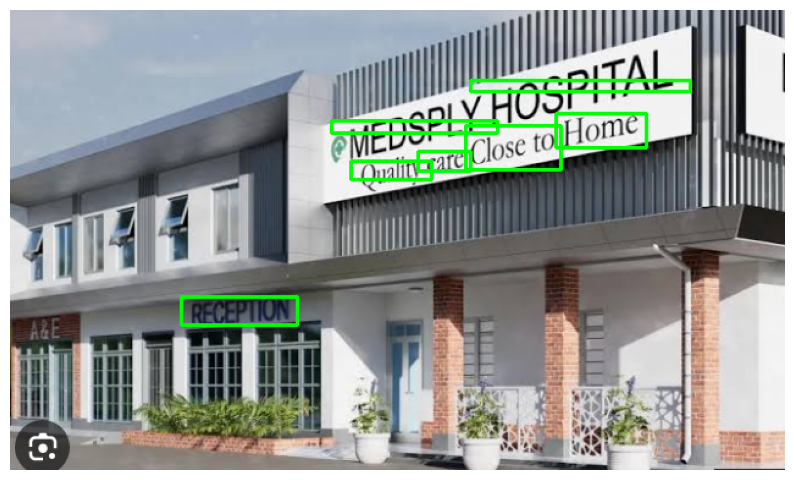

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_name)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for bbox, text, confidence in result:
    top_left = tuple(map(int, bbox[0]))
    bottom_right = tuple(map(int, bbox[2]))
    cv2.rectangle(img, top_left, bottom_right, (0, 255, 0), 2)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis('off')
plt.show()